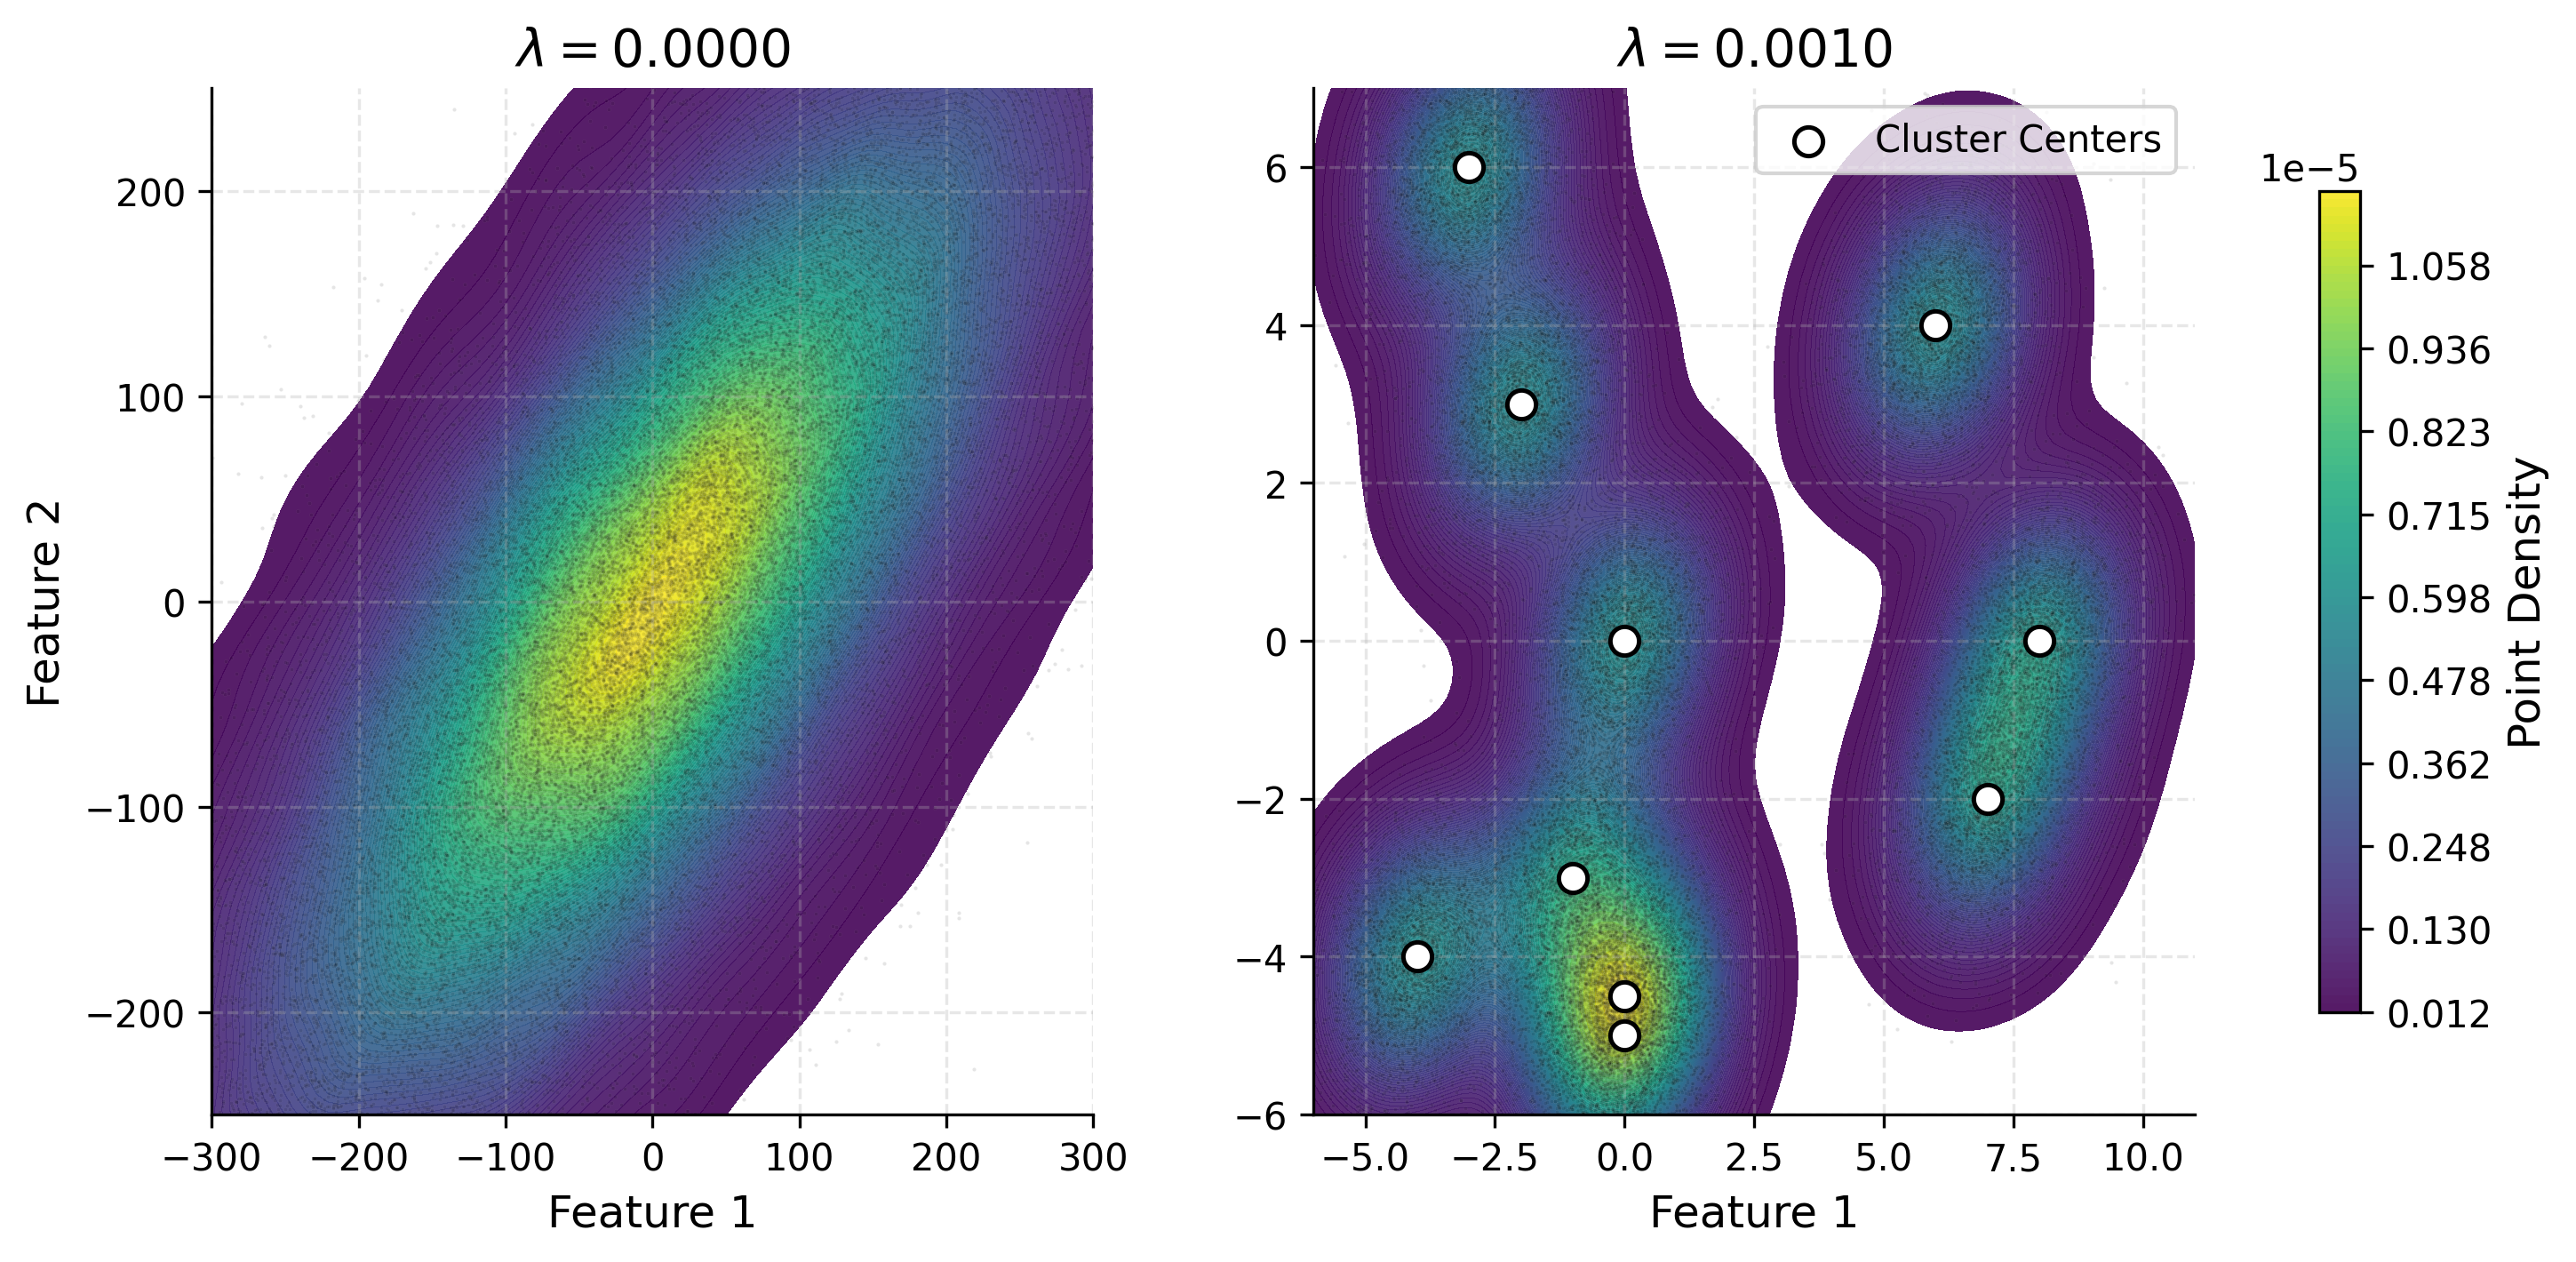

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal

# ===================== 全局风格设置（学术出版/高清演示标准） =====================
plt.rcParams.update({
    # 字体设置：英文用DejaVu Sans，中文可替换为SimHei/Arial Unicode MS
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    # 边框优化：去除上、右冗余边框
    "axes.spines.top": False,
    "axes.spines.right": False,
    # 网格设置：浅灰虚线，不抢数据焦点
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    # 高清输出设置
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.format": "png"  # 论文推荐换成pdf/eps矢量格式
})

# ===================== 数据部分（替换为你的真实数据即可） =====================
# 固定随机种子，保证模拟数据可复现
np.random.seed(42)

# 1. λ=0.0000 数据：大范围分散的单峰分布（和原图分布匹配）
mean_0 = [0, 0]
cov_0 = [[20000, 15000], [15000, 20000]]  # 控制分散程度
data_0 = multivariate_normal.rvs(mean=mean_0, cov=cov_0, size=50000)

# 2. λ=0.0010 数据：多峰聚类分布+聚类中心（和原图白点位置匹配）
cluster_centers = np.array([
    [-3, 6], [-2, 3], [-4, -4], [0, -5], [-1, -3],
    [0, 0], [6, 4], [8, 0], [7, -2], [0, -4.5]
])
cov_1 = [[0.8, 0.2], [0.2, 0.8]]  # 每个聚类的紧凑程度
data_1 = np.vstack([
    multivariate_normal.rvs(mean=m, cov=cov_1, size=5000)
    for m in cluster_centers
])

# ===================== 绘制美化后的双图 =====================
# 画布尺寸：12:5 比例协调，适配PPT/论文双栏排版
fig, (ax_left, ax_right) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# ---------------------- 左图：λ=0.0000 ----------------------
ax = ax_left
# 绘制平滑密度热力图（核心，体现分布密度）
sns.kdeplot(
    x=data_0[:, 0], y=data_0[:, 1],
    fill=True, cmap="viridis",  # viridis是官方推荐的色盲友好配色
    levels=100, thresh=0.01, alpha=0.9, ax=ax
)
# 叠加少量散点，保留原始数据特征（可选，不想保留可删除）
sns.scatterplot(
    x=data_0[:, 0], y=data_0[:, 1],
    s=1, alpha=0.1, color="black", ax=ax
)
# 标题&标签
ax.set_title(r"$\lambda = 0.0000$", fontweight="bold")
ax.set_xlabel("Feature 1")  # 替换为你的X轴实际含义，比如PC1/t-SNE 1
ax.set_ylabel("Feature 2")  # 替换为你的Y轴实际含义，比如PC2/t-SNE 2
# 坐标轴范围（和原图匹配，可按需调整）
ax.set_xlim(-300, 300)
ax.set_ylim(-250, 250)

# ---------------------- 右图：λ=0.0010 ----------------------
ax = ax_right
# 绘制密度热力图
sns.kdeplot(
    x=data_1[:, 0], y=data_1[:, 1],
    fill=True, cmap="viridis",
    levels=100, thresh=0.01, alpha=0.9, ax=ax
)
# 叠加散点
sns.scatterplot(
    x=data_1[:, 0], y=data_1[:, 1],
    s=1, alpha=0.1, color="black", ax=ax
)
# 绘制聚类中心（白点+黑边，醒目不融合）
center_scatter = ax.scatter(
    cluster_centers[:, 0], cluster_centers[:, 1],
    s=60, color="white", edgecolor="black", linewidth=1.2, zorder=10,
    label="Cluster Centers"
)
# 标题&标签
ax.set_title(r"$\lambda = 0.0010$", fontweight="bold")
ax.set_xlabel("Feature 1")
ax.set_ylabel("")  # 共享Y轴，避免重复标签
# 坐标轴范围
ax.set_xlim(-6, 11)
ax.set_ylim(-6, 7)
# 添加图例
ax.legend(handles=[center_scatter], loc="upper right")

# ===================== 全局收尾优化 =====================
# 对齐双图Y轴，保证排版工整
fig.align_ylabels([ax_left, ax_right])
# 调整双图间距
plt.subplots_adjust(wspace=0.25)
# 添加全局密度色标，统一说明颜色含义
fig.colorbar(
    ax_left.collections[0],
    ax=[ax_left, ax_right],
    shrink=0.8,
    label="Point Density"
)

# 保存图片+显示
plt.savefig("lambda_distribution_optimized.png", bbox_inches="tight")
plt.show()